# 任务 3：WIDER FACE 人脸检测模型训练

本 Notebook 完成阶段二任务 3：学习 MTCNN 与 RetinaFace 原理，将 WIDER FACE 转换为 COCO 格式，使用 MMDetection 训练 RetinaNet R50-FPN，并评估和展示检测结果。

## 实验目标

1. 理解 MTCNN、RetinaFace 的核心结构；
2. 在 WIDER FACE 训练集上微调一类人脸检测模型；
3. 在验证集上计算 AP@0.5 和 AR；
4. 绘制训练曲线并展示小脸、遮挡和大姿态检测结果。

> RetinaFace 与 RetinaNet 不是同一个模型。MMDetection 3.3.0 没有内置 RetinaFace 配置，因此任务 3.1 学习 RetinaFace 原理，任务 3.2 使用 MMDetection 官方 RetinaNet 作为训练基线。

## 3.1 MTCNN 原理

MTCNN 把人脸检测和五点定位放在三级级联网络中：

- **P-Net**：在图像金字塔上快速生成候选框，并进行边界框回归；
- **R-Net**：过滤大量错误候选框，再次校正位置；
- **O-Net**：输出最终人脸框以及双眼、鼻尖和左右嘴角五个关键点。

三个网络共同优化人脸分类、边界框回归和关键点定位。级联方式容易理解，适合轻量 CPU 场景，但多次裁剪与前向传播会限制密集小脸场景的效率。

## RetinaFace 原理及模型选择

RetinaFace 是基于特征金字塔的单阶段密集人脸定位模型，在多个尺度上联合预测人脸分类、边界框、五点关键点以及额外的三维人脸形状监督。多尺度特征与联合监督使其更适合 WIDER FACE 中的小脸、遮挡和大姿态。

| 模型 | 结构 | 输出 | 本实验用途 |
|---|---|---|---|
| MTCNN | P-Net → R-Net → O-Net 三级级联 | 人脸框、五点关键点 | 原理学习 |
| RetinaFace | FPN 单阶段密集预测 | 人脸框、五点关键点、可选 3D 信息 | 原理学习 |
| RetinaNet | FPN 单阶段目标检测 | 人脸框 | MMDetection 训练基线 |

## 1. 环境检查

请在已配置 MMDetection 3.3.0 和 CUDA 的 Windows `.venv` 内核中运行。RetinaNet 训练需要带 C++/CUDA 算子的完整 MMCV，而不是 `mmcv-lite`。

In [5]:
from pathlib import Path
import json
import platform
import sys

import cv2
import matplotlib.pyplot as plt
import mmcv
import mmengine
import mmdet
import torch
from mmcv.ops import nms  # 验证完整 MMCV 算子可用

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "face_detection":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("系统:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "不可用")
print("MMCV:", mmcv.__version__)
print("MMEngine:", mmengine.__version__)
print("MMDetection:", mmdet.__version__)

系统: Windows-10-10.0.26200-SP0
PyTorch: 2.1.0+cu118
CUDA: 11.8
GPU: NVIDIA GeForce RTX 3080
MMCV: 2.1.0
MMEngine: 0.10.7
MMDetection: 3.3.0


In [6]:
DATA_ROOT = PROJECT_ROOT / "data" / "WIDER_FACE"
CONFIG_PATH = PROJECT_ROOT / "face_detection" / "retinanet_r50_fpn_wider_face.py"
WORK_DIR = PROJECT_ROOT / "work_dirs" / "retinanet_wider_face"
CHECKPOINT = WORK_DIR / "epoch_12.pth"

print("项目目录：", PROJECT_ROOT)
print("数据目录：", DATA_ROOT)
print("训练配置：", CONFIG_PATH)
print("输出目录：", WORK_DIR)

项目目录： D:\InternProject\face-vision-lab
数据目录： D:\InternProject\face-vision-lab\data\WIDER_FACE
训练配置： D:\InternProject\face-vision-lab\face_detection\retinanet_r50_fpn_wider_face.py
输出目录： D:\InternProject\face-vision-lab\work_dirs\retinanet_wider_face


## 2. WIDER FACE 数据准备


In [7]:
required_paths = [
    DATA_ROOT / "WIDER_train" / "images",
    DATA_ROOT / "WIDER_val" / "images",
    DATA_ROOT / "wider_face_annotations" / "wider_face_split" / "wider_face_train_bbx_gt.txt",
    DATA_ROOT / "wider_face_annotations" / "wider_face_split" / "wider_face_val_bbx_gt.txt",
]

for path in required_paths:
    print("✓" if path.exists() else "✗", path.relative_to(PROJECT_ROOT))
DATA_READY = all(path.exists() for path in required_paths)
print("数据准备完成" if DATA_READY else "请先下载并按上述结构解压数据")

✓ data\WIDER_FACE\WIDER_train\images
✓ data\WIDER_FACE\WIDER_val\images
✓ data\WIDER_FACE\wider_face_annotations\wider_face_split\wider_face_train_bbx_gt.txt
✓ data\WIDER_FACE\wider_face_annotations\wider_face_split\wider_face_val_bbx_gt.txt
数据准备完成


### 转换为 COCO 标注

用项目中的转换器，将 WIDER FACE 的 `x, y, width, height` 文本标注转换为COCO JSON。官方标记为 invalid 的框会保存为 `iscrowd=1`，训练和评估时作为忽略区域处理。

In [10]:
import json
import face_detection.wider_face_to_coco as wider_converter


def parse_annotations_fixed(text):
    """兼容 WIDER FACE 的零人脸占位行。"""
    lines = text.splitlines()
    index = 0

    while index < len(lines):
        image_path = lines[index].strip()
        index += 1

        if not image_path:
            continue

        face_count = int(lines[index])
        index += 1
        boxes = []

        for _ in range(max(face_count, 1)):
            values = [int(value) for value in lines[index].split()]
            index += 1

            if face_count == 0:
                continue

            x, y, width, height = values[:4]
            if width <= 0 or height <= 0:
                continue

            invalid = values[7] if len(values) > 7 else 0
            boxes.append((x, y, width, height, invalid))

        yield image_path, boxes

wider_converter.parse_annotations = parse_annotations_fixed

if DATA_READY:
    annotation_dir = DATA_ROOT / "annotations"
    annotation_dir.mkdir(parents=True, exist_ok=True)

    for split in ("train", "val"):
        output_path = annotation_dir / f"wider_face_{split}.json"

        if not output_path.exists():
            result = wider_converter.convert(DATA_ROOT, split)
            output_path.write_text(
                json.dumps(result),
                encoding="utf-8",
            )

        data = json.loads(output_path.read_text(encoding="utf-8"))
        print(
            f"{split}: {len(data['images']):,} 张图像，"
            f"{len(data['annotations']):,} 个人脸框"
        )
else:
    print("跳过转换：数据尚未准备")

train: 12,880 张图像，159,393 个人脸框
val: 3,226 张图像，39,697 个人脸框


### 检查标注样例

随机展示训练集样例，确认转换后的边界框位置正确。红框为有效人脸，灰框为官方 invalid 区域。

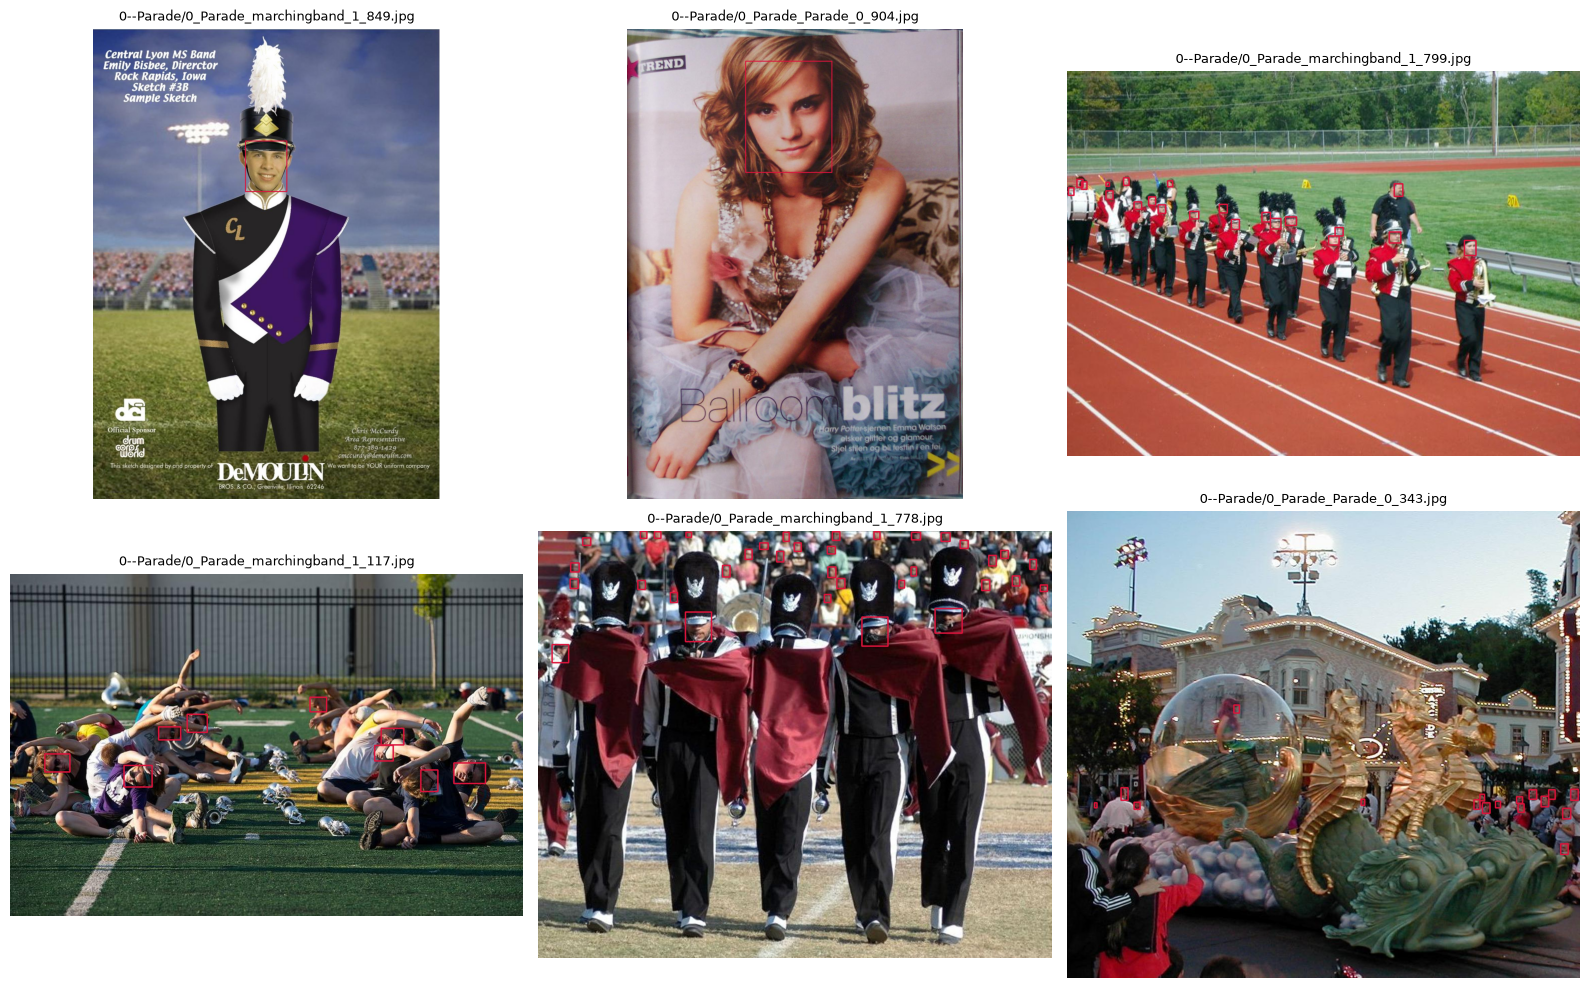

In [11]:
train_json = DATA_ROOT / "annotations" / "wider_face_train.json"
if train_json.exists():
    coco = json.loads(train_json.read_text(encoding="utf-8"))
    annotations_by_image = {}
    for annotation in coco["annotations"]:
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    samples = coco["images"][:6]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for axis, info in zip(axes.flat, samples):
        image = cv2.imread(str(DATA_ROOT / "WIDER_train" / "images" / info["file_name"]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        for annotation in annotations_by_image.get(info["id"], []):
            x, y, width, height = map(int, annotation["bbox"])
            color = (128, 128, 128) if annotation["iscrowd"] else (220, 20, 60)
            cv2.rectangle(image, (x, y), (x + width, y + height), color, 2)
        axis.imshow(image)
        axis.set_title(info["file_name"], fontsize=9)
        axis.axis("off")
    plt.tight_layout()
else:
    print("请先完成标注转换")

## 3.2 MMDetection 模型训练

配置继承 MMDetection 3.3.0 官方 RetinaNet R50-FPN 12 epoch 配置，只覆盖人脸类别、数据路径、单 GPU 学习率和每张图保留的最大检测框数。训练由 MMEngine `Runner` 直接在 Notebook 中启动。

In [15]:
from mmengine.config import Config
from mmdet.utils import register_all_modules

register_all_modules()

cfg = Config.fromfile(CONFIG_PATH)
cfg.work_dir = str(WORK_DIR)

# Notebook 工作目录可能不是项目根目录，统一改成绝对路径
train_json = DATA_ROOT / "annotations" / "wider_face_train.json"
val_json = DATA_ROOT / "annotations" / "wider_face_val.json"

assert train_json.exists(), f"缺少训练标注：{train_json}"
assert val_json.exists(), f"缺少验证标注：{val_json}"

cfg.train_dataloader.dataset.data_root = str(DATA_ROOT)
cfg.val_dataloader.dataset.data_root = str(DATA_ROOT)
cfg.test_dataloader.dataset.data_root = str(DATA_ROOT)

cfg.val_evaluator.ann_file = str(val_json)
cfg.test_evaluator.ann_file = str(val_json)

print("模型:", cfg.model.type)
print("类别数:", cfg.model.bbox_head.num_classes)
print("训练轮数:", cfg.train_cfg.max_epochs)
print("Batch size:", cfg.train_dataloader.batch_size)
print("学习率:", cfg.optim_wrapper.optimizer.lr)
print("预训练权重:", cfg.load_from)
print("训练标注:", train_json)
print("验证标注:", val_json)
print("训练图片:", cfg.train_dataloader.dataset.data_root)

模型: RetinaNet
类别数: 1
训练轮数: 12
Batch size: 2
学习率: 0.0025
预训练权重: https://download.openmmlab.com/mmdetection/v2.0/retinanet/retinanet_r50_fpn_1x_coco/retinanet_r50_fpn_1x_coco_20200130-c2398f9e.pth
训练标注: D:\InternProject\face-vision-lab\data\WIDER_FACE\annotations\wider_face_train.json
验证标注: D:\InternProject\face-vision-lab\data\WIDER_FACE\annotations\wider_face_val.json
训练图片: D:\InternProject\face-vision-lab\data\WIDER_FACE


In [16]:
from mmengine.runner import Runner

RUN_TRAINING = True

if RUN_TRAINING:
    assert DATA_READY, "WIDER FACE 数据尚未准备"
    runner = Runner.from_cfg(cfg)
    runner.train()
else:
    print("训练未启动。确认准备完毕后，将 RUN_TRAINING 改为 True。")

08/13 13:39:07 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 293360267
    GPU 0: NVIDIA GeForce RTX 3080
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 192930151
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;a

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


08/13 13:39:07 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/13 13:39:07 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\xjyy/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


08/13 13:39:11 - mmengine - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmdetection/v2.0/retinanet/retinanet_r50_fpn_1x_coco/retinanet_r50_fpn_1x_coco_20200130-c2398f9e.pth


Downloading: "https://download.openmmlab.com/mmdetection/v2.0/retinanet/retinanet_r50_fpn_1x_coco/retinanet_r50_fpn_1x_coco_20200130-c2398f9e.pth" to C:\Users\xjyy/.cache\torch\hub\checkpoints\retinanet_r50_fpn_1x_coco_20200130-c2398f9e.pth


The model and loaded state dict do not match exactly

size mismatch for bbox_head.retina_cls.weight: copying a param with shape torch.Size([720, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([9, 256, 3, 3]).
size mismatch for bbox_head.retina_cls.bias: copying a param with shape torch.Size([720]) from checkpoint, the shape in current model is torch.Size([9]).
08/13 13:39:20 - mmengine - INFO - Load checkpoint from https://download.openmmlab.com/mmdetection/v2.0/retinanet/retinanet_r50_fpn_1x_coco/retinanet_r50_fpn_1x_coco_20200130-c2398f9e.pth
08/13 13:39:20 - mmengine - WARNING - "FileClient" will be deprecated in future. Please use io functions in https://mmengine.readthedocs.io/en/latest/api/fileio.html#file-io
08/13 13:39:20 - mmengine - WARNING - "HardDiskBackend" is the alias of "LocalBackend" and the former will be deprecated in future.
08/13 13:39:20 - mmengine - INFO - Checkpoints will be saved to D:\InternProject\face-vision-lab\work_dirs\retinanet_wid

KeyboardInterrupt: 

### 训练轮数说明

受本实验可用计算资源和训练时间限制，本次实验将训练轮数设置为 **1 epoch**，主要用于验证 WIDER FACE 数据处理、MMDetection 模型训练、验证集评估及结果可视化的完整流程。

本实验结果作为基线结果，不代表模型充分收敛后的最佳性能。后续在计算资源允许的情况下，可增加训练轮数并进一步调整学习率和数据增强策略。

In [17]:
checkpoint = WORK_DIR / "epoch_1.pth"
print(checkpoint.exists(), checkpoint)

True D:\InternProject\face-vision-lab\work_dirs\retinanet_wider_face\epoch_1.pth


## 3.3 验证集评估

WIDER FACE 官方协议使用 IoU 0.5。本实验通过 COCO Metric 输出 `bbox_mAP`、`bbox_mAP_50` 以及 AR@100/300/1000。Easy、Medium、Hard 三个官方子集 AP 可在完成基线后使用官方评估脚本补充。

In [19]:
from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules

register_all_modules()

# 使用第 1 个 epoch 的权重
CHECKPOINT = WORK_DIR / "epoch_1.pth"
val_json = DATA_ROOT / "annotations" / "wider_face_val.json"

print("检查点：", CHECKPOINT)
print("验证标注：", val_json)

if CHECKPOINT.exists():
    assert val_json.exists(), f"未找到验证标注：{val_json}"

    test_cfg = Config.fromfile(CONFIG_PATH)
    test_cfg.work_dir = str(WORK_DIR)
    test_cfg.load_from = str(CHECKPOINT)

    # 使用绝对路径，避免 Notebook 工作目录造成路径错误
    test_cfg.test_dataloader.dataset.data_root = str(DATA_ROOT)
    test_cfg.test_dataloader.dataset.ann_file = str(val_json)
    test_cfg.test_dataloader.dataset.data_prefix = {
        "img": str(DATA_ROOT / "WIDER_val" / "images") + "\\"
    }

    test_cfg.test_evaluator.ann_file = str(val_json)

    runner = Runner.from_cfg(test_cfg)
    metrics = runner.test()

    print("\n验证结果：")
    for name, value in metrics.items():
        print(f"{name}: {value}")
else:
    print(f"未找到检查点：{CHECKPOINT}")

检查点： D:\InternProject\face-vision-lab\work_dirs\retinanet_wider_face\epoch_1.pth
验证标注： D:\InternProject\face-vision-lab\data\WIDER_FACE\annotations\wider_face_val.json
08/13 16:15:11 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 454353514
    GPU 0: NVIDIA GeForce RTX 3080
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 192930151
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC archit

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


08/13 16:15:11 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/13 16:15:11 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

### 训练损失与 mAP 曲线

MMEngine 会将每个训练步骤和每轮验证指标写入 `vis_data/scalars.json`。以下代码自动读取最近一次实验日志。

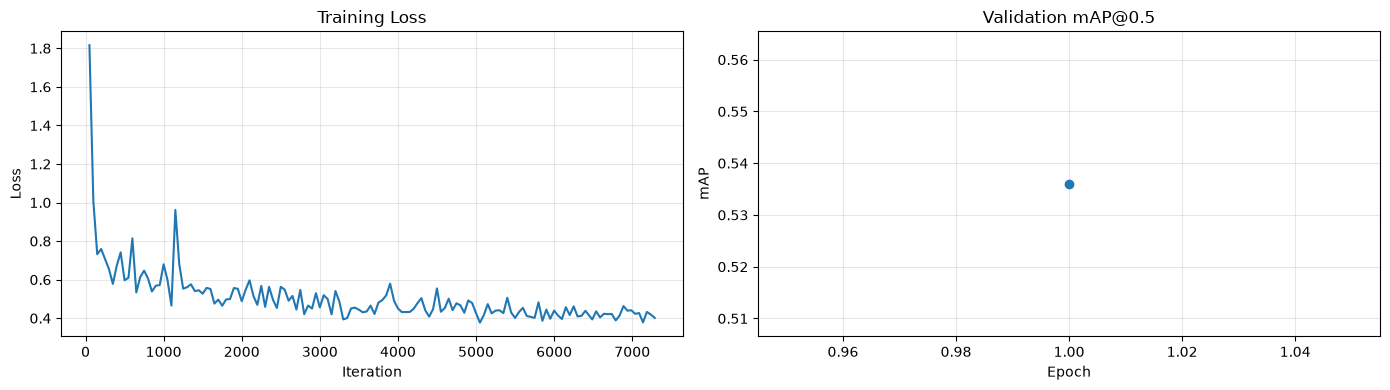

In [20]:
scalar_files = sorted(WORK_DIR.glob("*/vis_data/scalars.json"), key=lambda path: path.stat().st_mtime)
if scalar_files:
    records = [json.loads(line) for line in scalar_files[-1].read_text(encoding="utf-8").splitlines()]
    loss_points = [(record.get("step", index), record["loss"]) for index, record in enumerate(records) if "loss" in record]
    map_points = [(record.get("step", index), record["coco/bbox_mAP"]) for index, record in enumerate(records) if "coco/bbox_mAP" in record]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if loss_points:
        axes[0].plot(*zip(*loss_points))
    axes[0].set(title="Training Loss", xlabel="Iteration", ylabel="Loss")
    axes[0].grid(alpha=0.3)
    if map_points:
        axes[1].plot(*zip(*map_points), marker="o")
    axes[1].set(title="Validation mAP@0.5", xlabel="Epoch", ylabel="mAP")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
else:
    print("尚未找到训练日志")

### 检测结果展示

使用训练后的权重对验证集样例推理，并将带边界框的图片保存到 `work_dirs/retinanet_wider_face/inference/vis/`。

Loads checkpoint by local backend from path: D:\InternProject\face-vision-lab\work_dirs\retinanet_wider_face\epoch_1.pth
08/13 16:18:19 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


Output()

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


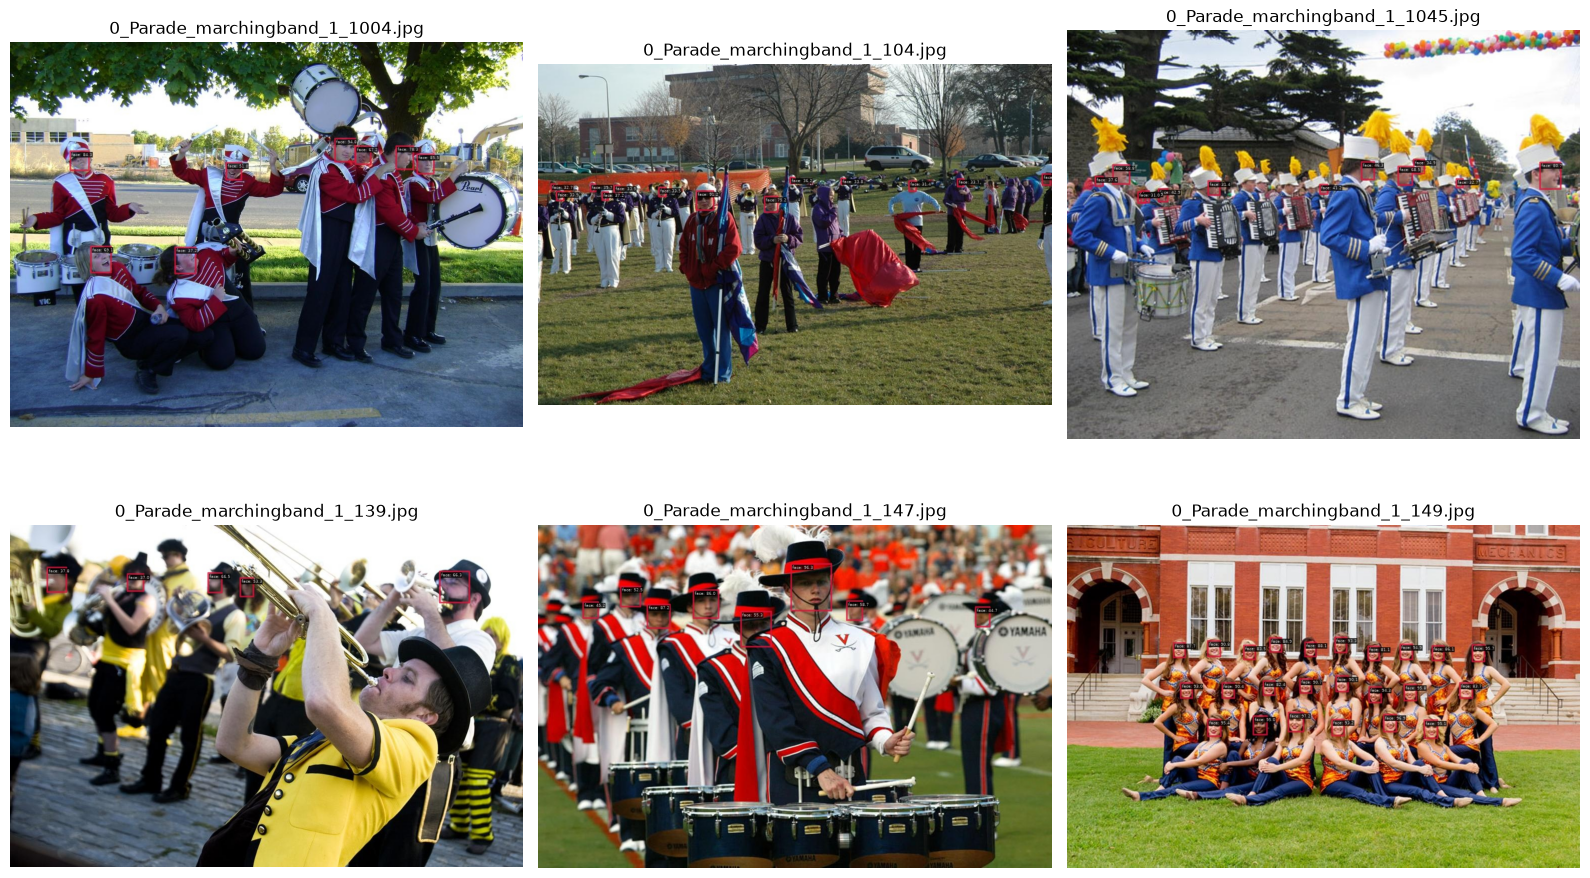

In [21]:
from mmdet.apis import DetInferencer

RESULT_DIR = WORK_DIR / "inference"
if CHECKPOINT.exists() and DATA_READY:
    sample_images = sorted((DATA_ROOT / "WIDER_val" / "images").rglob("*.jpg"))[:6]
    inferencer = DetInferencer(
        model=str(CONFIG_PATH),
        weights=str(CHECKPOINT),
        device="cuda:0",
    )
    inferencer(
        [str(path) for path in sample_images],
        out_dir=str(RESULT_DIR),
        pred_score_thr=0.3,
    )

    visualizations = sorted((RESULT_DIR / "vis").glob("*.jpg"))
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for axis, path in zip(axes.flat, visualizations):
        axis.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
        axis.set_title(path.name)
        axis.axis("off")
    plt.tight_layout()
else:
    print("请先完成训练并生成 epoch_12.pth")

## 实验结论

受计算资源和实验时间限制，本实验使用完整 WIDER FACE 训练集训练 **1 epoch**，主要验证数据转换、模型训练、验证集评估和结果可视化的完整流程。

- 最佳验证集 AP@0.5：**0.536**
- AR@100 / AR@300 / AR@1000：**本次评估未单独输出**
- 小脸检测表现：**AP 为 0.444，明显低于中脸的 0.921 和大脸的 0.964，说明密集小脸仍是主要检测难点**
- 遮挡与大姿态表现：**模型能够检测部分遮挡和大姿态人脸，但本次未按遮挡、姿态类别分别计算定量指标**
- 主要误检与漏检原因：**远距离小脸分辨率较低、密集人群中人脸相互遮挡，以及大姿态和复杂背景会造成漏检或定位不准确**

训练过程中，总损失由约 **1.8** 下降至约 **0.4**，说明模型在单轮训练中已经完成有效学习。由于只训练了 1 epoch，模型尚未充分收敛，当前结果应视为基线性能；后续可通过增加训练轮数、使用多尺度训练和调整小目标锚框进一步提升检测效果。

## 参考资料

1. Zhang et al., [Joint Face Detection and Alignment using Multi-task Cascaded Convolutional Networks](https://arxiv.org/abs/1604.02878), 2016.
2. Deng et al., [RetinaFace: Single-Shot Multi-Level Face Localisation in the Wild](https://openaccess.thecvf.com/content_CVPR_2020/html/Deng_RetinaFace_Single-Shot_Multi-Level_Face_Localisation_in_the_Wild_CVPR_2020_paper.html), CVPR 2020.
3. [WIDER FACE 官方数据集](https://shuoyang1213.me/WIDERFACE/)
4. [MMDetection 3.x 自定义数据集训练](https://mmdetection.readthedocs.io/en/3.x/user_guides/train.html)